In [1]:
# import data 
import pandas as pd
from pathlib import Path 

# find current working directory
data_path1 = Path.cwd().parent / 'Data' / 'linear.csv'
data_path2 = Path.cwd().parent/ 'Data' / 'non_linear.csv'
data_path3 = Path.cwd().parent / 'Data' / 'target.csv'

# load data into respective objects
linear = pd.read_csv(data_path1)
non_linear = pd.read_csv(data_path2)
target = pd.read_csv(data_path3)


In [2]:
# train linear dataset
from sklearn.model_selection import train_test_split

# target varible 
Y = target[['Survived']]

# inputs 
X = linear.copy()

# 70/30 split 
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X, Y, test_size = 0.3, shuffle = True, random_state = 42)


# StraifiedKfold (T-Test)
- In this phase we will create a distribution of accuracy evaluation scores for each model. Then use a Paired T-Test to see if the difference between the 10 pairs is significant. 

Result: Since there is no statistical difference between the two models we need to consider a secodary criteria. 

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from scipy import stats

# Define the cross validation strategy 
cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state= 42)

# get 10 scores for each model
lr_scores = cross_val_score(lr, X_train1, Y_train1, cv = cv, scoring = "accuracy")
svm_scores = cross_val_score(svm, X_train2, Y_train2, cv = cv, scoring = 'accuracy')

# perform Paired T-Test
t_stat, p_value = stats.ttest_rel(lr_scores, svm_scores)

# print results
print(f'Logistic Regression Mean {lr_scores.mean():.4f}')
print(f'Support Vector Machine Mean {svm_scores.mean():.4f}')
print(f'P Values {p_value:.4f}')

# result loop

if p_value < 0.05: 
    print('Statistically Significant')
else: 
    print('No significant difference ()')

# Calibration 
- In this phase we'll test the confidence levels of the chosen two models. This ensures predicted confidence levels map directly into real world frequencies, which is crucial for decision making. A model can be accurate but uncalibrated which leads to overconfidence and vice versa. 

Result: The logistic regression model when compared to the SVM performs much better in terms of confidence levels. Logistic Regression model not only has a lower brier score, but also is very under confident with probabilities above the 50% threshold. 

In [12]:
# import sklearn and configure model for the best parameters
from sklearn.linear_model import LogisticRegression 

# instanstation process 
lr = LogisticRegression(C=10, penalty='l1', solver='liblinear')

# fit model on the training data
lr.fit(X_train1, Y_train1)


C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=10, penalty='l1', solver='liblinear')

C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


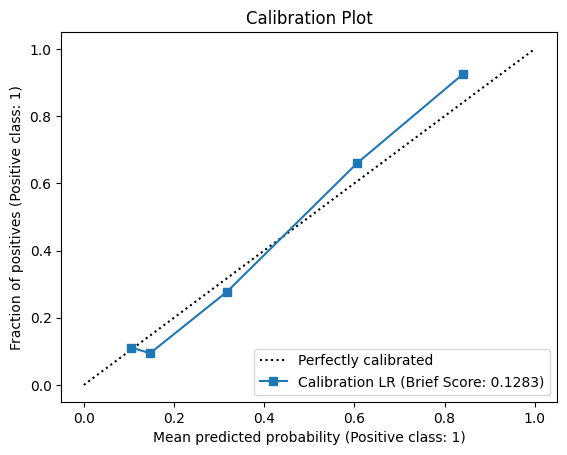

In [13]:
# calculate calibaration curve using probabilities and brier score for logistic regression 
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibratedClassifierCV

# Apply platt scaling
calibrated_lr = CalibratedClassifierCV(estimator= lr, method = 'sigmoid', cv = 5, n_jobs = -1)

# train model on data 
calibrated_lr.fit(X_train1, Y_train1)

# get probabilties 
lr_probs = calibrated_lr.predict_proba(X_test1)[:,1]

# calculate brier score
lr_brier = brier_score_loss(Y_test1, lr_probs)

# plot the display
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt 
CalibrationDisplay.from_estimator(calibrated_lr,  X_test1, Y_test1, n_bins= 5, strategy= 'quantile', name = f'Calibration LR (Brief Score: {lr_brier:.4f})')
plt.title('Calibration Plot')
plt.show()

In [6]:
# training phase for non linear dataset 

# target variable
Y = target['Survived']

# inputs 
X = non_linear.copy() 

# 70/30 split 
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(X, Y, test_size = 0.3, shuffle = True, random_state = 42)


In [7]:
# Deploy SVM with the best settings 
from sklearn.svm import SVC

# instantation process 
svm = SVC(C=10, gamma=1)

# fit model onto data
svm.fit(X_train2, Y_train2)


SVC(C=10, gamma=1)

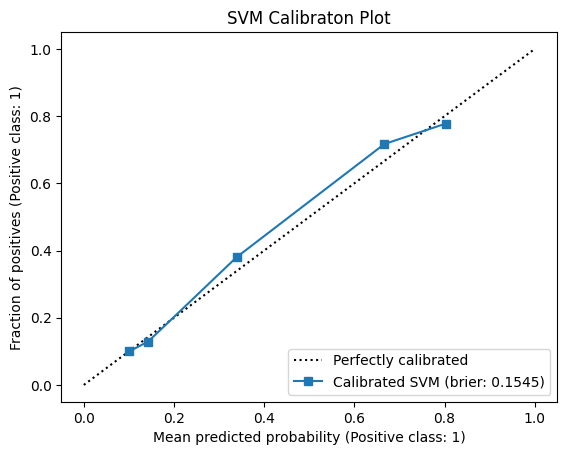

In [8]:
# calculate the calibration curve for SVM model 
from sklearn.calibration import CalibratedClassifierCV

# calculate calibration curve 
calibrated_svc = CalibratedClassifierCV(svm, method = 'isotonic', cv = 5)

# fit data on model 
calibrated_svc.fit(X_train2, Y_train2)

#calculate probabilites
svm_probs = calibrated_svc.predict_proba(X_test2)[:,1]

# breir score
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(Y_test2, svm_probs)

# plot the display 
from sklearn.calibration import CalibrationDisplay
disp = CalibrationDisplay.from_estimator(calibrated_svc, X_test2, Y_test2, n_bins = 5, name = f'Calibrated SVM (brier: {brier:.4f})', strategy='quantile' )
# add basline for "Perfect Calibration"
plt.title('SVM Calibraton Plot')
plt.show()

# Model Winner
- Logistic Regression is the winner and performs very well with a brier score of 0.126. The line also hugs the diagnoal line very closely, signaling a confidence in probabilites. The SVM line weaves alot more and is underconfident in the middle and overconfident on the high end. 